In [ ]:
!pip install -U bitsandbytes>=0.46.1 accelerate

In [ ]:
!pip install -U z3

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.6 MB/s eta 0:00:00
  Created wheel for z3: filename=z3-0.2.0-py3-none-any.whl size=26629 sha256=5b2597e581776c49a86097b7b902c918d3f02ebecec2f75d6eb950fc5925e6d8
  Stored in directory: /root/.cache/pip/wheels/4b/70/2e/7e2249bba127945c102c670be2fb35d9773dc3571475e38b24
Successfully built z3


In [ ]:
from google.colab import drive
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/run2_phi"

if os.path.exists(PROJECT_DIR):
    print("Found existing folder")
    print(os.listdir(PROJECT_DIR))
else:
    print("Folder not found")

Found existing folder
['hard_failure_set_20.json', 'models', 'tensors', 'data', 'final_balanced_sweep.json', 'steering_vector.pt', 'checkpoints']


In [ ]:

PROJECT_DIR = '/content/drive/MyDrive/run2_phi'
#os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/checkpoints", exist_ok=True)

In [ ]:
# 3. Check for the Phase 2 data
if os.path.exists(f"{PROJECT_DIR}/data/clusters.json"):
    print("Access Confirmed! Account A can now read Account B's data.")
    with open(f"{PROJECT_DIR}/data/clusters.json", 'r') as f:
        import json
        data = json.load(f)
        print(f"Found {len(data)} clusters. Ready for Phase 3.")
else:
    print(f"Shortcut not found. Check if the folder name is exactly '{PROJECT_DIR.split('/')[-1]}' in My Drive.")

Access Confirmed! Account A can now read Account B's data.
Found 250 clusters. Ready for Phase 3.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_id = "mistralai/Mistral-7B-Instruct-v0.2" # Updated model ID

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_enable_fp32_cpu_offload=True # Added for consistency and potential future 8-bit loading
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

In [ ]:
# 1. Setup paths
PROJECT_DIR = '/content/drive/MyDrive/run2_phi'
SAVE_PATH = f"{PROJECT_DIR}/models/mistral"

import os
os.makedirs(SAVE_PATH, exist_ok=True)

# 2. Save the objects that are already in memory from the cell above
print(f"--- Saving model and tokenizer to: {SAVE_PATH} ---")

# Save the tokenizer
tokenizer.save_pretrained(SAVE_PATH)

# Save the model weights (the 4-bit quantized version)
model.save_pretrained(SAVE_PATH, safe_serialization=True)

print("Done! Everything is now safe on Google Drive.")

--- Saving model and tokenizer to: /content/drive/MyDrive/run2_phi/models/mistral ---


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done! Everything is now safe on Google Drive.


In [ ]:

import json
import os
import random

# Ensure directory exists
DATA_DIR = f"{PROJECT_DIR}/data"
os.makedirs(DATA_DIR, exist_ok=True)

class ProfessionalClusterGenerator:
    def __init__(self):
        # Increased linguistic pool for variety
        self.subjects = ["The database", "The reactor", "The encryption", "The satellite",
                         "The neural net", "The cooling system", "The firewall", "The uplink"]
        self.states = ["is online", "is stable", "is verified", "is active",
                       "is synchronized", "is fluctuating", "is bypassed"]
        self.clusters = []

    def generate_deductive(self, cid):
        """Generates Modus Ponens and Modus Tollens clusters."""
        s = random.sample(self.subjects, 2)
        st = random.sample(self.states, 2)

        world = f"Rule: If {s[0]} {st[0]}, then {s[1]} {st[1]}.";

        return {
            "cluster_id": cid,
            "type": "deductive",
            "textual_world": world,
            "questions": [
                {"q": f"Fact: {s[0]} {st[0]}. Question: Is {s[1]} {st[1]}?", "target": "True"}, # Modus Ponens
                {"q": f"Fact: {s[1]} is not {st[1]}. Question: Is {s[0]} {st[0]}?", "target": "False"} # Modus Tollens
            ]
        }

    def generate_abductive(self, cid):
        """Generates 'Best Explanation' (Inference to the Best Explanation) clusters."""
        s = random.sample(self.subjects, 3)
        st = random.sample(self.states, 3)

        # Structure: (A -> B) and (C -> B).
        world = f"Rules: 1. If {s[0]} {st[0]}, then {s[1]} {st[1]}. 2. If {s[2]} {st[2]}, then {s[1]} {st[1]}.";

        return {
            "cluster_id": cid,
            "type": "abductive",
            "textual_world": world,
            "questions": [
                {"q": f"Observation: {s[1]} {st[1]}. Fact: {s[2]} is not {st[2]}. Question: Did {s[0]} {st[0]}?", "target": "True"}
            ]
        }

    def build_dataset(self, count=500):
        print(f"Generating {count} verified clusters...")
        for i in range(count // 2):
            self.clusters.append(self.generate_deductive(f"D_{i}"))
            self.clusters.append(self.generate_abductive(f"A_{i}"))

        save_path = f"{DATA_DIR}/clusters.json"
        with open(save_path, 'w') as f:
            json.dump(self.clusters, f, indent=4)
        print(f"Phase 1 Complete: {len(self.clusters)} clusters saved to {save_path}")

gen = ProfessionalClusterGenerator()
gen.build_dataset(250)

Generating 250 verified clusters...
Phase 1 Complete: 250 clusters saved to /content/drive/MyDrive/run2_phi/data/clusters.json


In [ ]:
#After switching from CPU to GPU
# Check for clusters.json (Phase 1 artifact)
if os.path.exists(f"{PROJECT_DIR}/data/clusters.json"):
    print("Clusters.json found. Phase 1 is safe.")

# Check for model weights (Phase 0 artifact)
if os.path.exists(f"{PROJECT_DIR}/models/phi"):
    print("Model weights found. No re-download needed.")

Clusters.json found. Phase 1 is safe.
Model weights found. No re-download needed.


In [ ]:
!pip install -U bitsandbytes>=0.46.1
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, AutoConfig

MODEL_DIR = f"{PROJECT_DIR}/models/mistral" # Updated to mistral folder
os.makedirs(MODEL_DIR, exist_ok=True)

print("Created:", MODEL_DIR)


tokenizer.save_pretrained(MODEL_DIR)
model.save_pretrained(MODEL_DIR)

print("Model saved to Drive")

Created: /content/drive/MyDrive/run2_phi/models/mistral


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to Drive


In [ ]:
import json
import os

# Define the path to your data

DATA_PATH = f"{PROJECT_DIR}/data/clusters.json"

# Load the clusters back into memory
if os.path.exists(DATA_PATH):
    with open(DATA_PATH, 'r') as f:
        clusters = json.load(f)
    print(f"Successfully loaded {len(clusters)} clusters from Drive.")
else:
    print("Error: clusters.json not found. Did you mount the Drive correctly?")

Successfully loaded 250 clusters from Drive.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig


MODEL_PATH = f"{PROJECT_DIR}/models/mistral"


quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True
)

print("Loading model and tokenizer from Drive.")

#  Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

# Load Model to GPU
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

print(f"Model loaded and active on: {model.device}")

Loading model and tokenizer from Drive.


`torch_dtype` is deprecated! Use `dtype` instead!
/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded and active on: cuda:0


In [ ]:
import torch
import json
import os
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import numpy as np
import os
import torch
import json
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

In [ ]:
def extract_answer_final(text):
    text = text.lower().strip()
    if "final answer: true" in text or "answer is true" in text: return "True"
    if "final answer: false" in text or "answer is false" in text: return "False"

    truth_terms = ["true", "yes", "correct", "is stable", "is online", "is synchronized"]
    false_terms = ["false", "no", "incorrect", "is not", "is bypassed", "is fluctuating"]

    last_truth = max([text.rfind(t) for t in truth_terms])
    last_false = max([text.rfind(t) for t in false_terms])

    if last_truth > last_false: return "True"
    elif last_false > last_truth: return "False"
    return "Unknown"

In [ ]:
def run_phase_2_production(clusters, model, tokenizer, condition):
    output_path = f"{PROJECT_DIR}/data/phase2_{condition}.json"
    results = []

    # Check for resumption
    if os.path.exists(output_path):
        with open(output_path, 'r') as f:
            results = json.load(f)
        processed_ids = {r['cluster_id'] for r in results}
        print(f"Resuming {condition}: {len(processed_ids)} clusters already saved.")
    else:
        processed_ids = set()

    remaining_clusters = [c for c in clusters if c['cluster_id'] not in processed_ids]

    for i, cluster in enumerate(tqdm(remaining_clusters, desc=f"Phase 2: {condition}")):
        for q_data in cluster['questions']:
            if condition == "direct":
                prompt = f"### CONTEXT\n{cluster['textual_world']}\n\n### QUESTION\n{q_data['q']}\n\n### INSTRUCTION\nAnswer only 'True' or 'False'.\n\n### FINAL ANSWER\n"
                max_tokens = 15
            elif condition == "cot":
                prompt = f"### CONTEXT\n{cluster['textual_world']}\n\n### QUESTION\n{q_data['q']}\n\n### REASONING\nLet's think step by step:\n"
                max_tokens = 256
            else: # solver_augmented
                symbolic_context = cluster.get('symbolic_world', 'Verified Logic.')
                prompt = f"### CONTEXT\n{cluster['textual_world']}\n\n### LOGIC CHECK\n{symbolic_context}\n\n### QUESTION\n{q_data['q']}\n\n### FINAL ANSWER\n"
                max_tokens = 32

            inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=max_tokens, temperature=0.1, do_sample=False)

            gen_text = tokenizer.decode(outputs[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)

            results.append({
                "cluster_id": cluster['cluster_id'],
                "condition": condition,
                "target": q_data['target'],
                "predicted": extract_answer_final(gen_text),
                "raw_response": gen_text
            })

        if (i + 1) % 5 == 0: # Save every 5 clusters
            with open(output_path, 'w') as f:
                json.dump(results, f, indent=4)

    with open(output_path, 'w') as f:
        json.dump(results, f, indent=4)
    print(f" {condition} complete.")

In [ ]:
run_phase_2_production(clusters, model, tokenizer, "direct")

Resuming direct: 250 clusters already saved.


Phase 2: direct: 0it [00:00, ?it/s]

 direct complete.


In [ ]:
import json
with open(f"{PROJECT_DIR}/data/phase2_direct.json", 'r') as f:
    data = json.load(f)

correct = sum(1 for d in data if d['predicted'] == d['target'])
total = len(data)
print(f"Direct Accuracy: {correct/total:.2%} ({correct}/{total})")

Direct Accuracy: 62.40% (234/375)


In [ ]:
run_phase_2_production(clusters, model, tokenizer, "solver_augmented")

Resuming solver_augmented: 250 clusters already saved.


Phase 2: solver_augmented: 0it [00:00, ?it/s]

 solver_augmented complete.


In [ ]:
import json
with open(f"{PROJECT_DIR}/data/phase2_solver_augmented.json", 'r') as f:
    solver_data = json.load(f)

correct = sum(1 for d in solver_data if d['predicted'] == d['target'])
total = len(solver_data)
print(f"Solver-Augmented Accuracy: {correct/total:.2%} ({correct}/{total})")

Solver-Augmented Accuracy: 64.00% (240/375)


In [ ]:
import json
with open(f"{PROJECT_DIR}/data/phase2_cot.json", 'r') as f:
    solver_data = json.load(f)

correct = sum(1 for d in solver_data if d['predicted'] == d['target'])
total = len(solver_data)
print(f"Solver-Augmented Accuracy: {correct/total:.2%} ({correct}/{total})")

Solver-Augmented Accuracy: 65.60% (246/375)


In [ ]:
import json
import pandas as pd
import os

def generate_iclr_results_summary():

    files = {
        "Direct (Baseline)": "phase2_direct.json",
        "Solver-Augmented": "phase2_solver_augmented.json",
        "Chain-of-Thought (CoT)": "phase2_cot.json"
    }

    summary_stats = []

    for label, filename in files.items():
        path = os.path.join(PROJECT_DIR, "data", filename)
        if os.path.exists(path):
            with open(path, 'r') as f:
                data = json.load(f)

            # The extractor we built last night marks failed logic as "Unknown"
            valid_data = [d for d in data if d['predicted'] != "Unknown"]
            correct = sum(1 for d in valid_data if d['predicted'] == d['target'])
            total = len(data)
            accuracy = (correct / total) * 100 if total > 0 else 0

            summary_stats.append({
                "Method": label,
                "Accuracy": f"{accuracy:.2f}%",
                "Correct": correct,
                "Total Samples": total,
                "Failures": total - correct
            })

    df = pd.DataFrame(summary_stats)
    print("\n" + "="*60)
    print("ICLR 2026: FINAL BEHAVIORAL EVALUATION (mistral7b)")
    print("="*60)
    if not df.empty:
        print(df.to_string(index=False))
    else:
        print("No result files found. Check your /data/ folder path.")
    print("="*60)

# Execute the summary
generate_iclr_results_summary()


ICLR 2026: FINAL BEHAVIORAL EVALUATION (mistral7b)
                Method Accuracy  Correct  Total Samples  Failures
     Direct (Baseline)   62.40%      234            375       141
      Solver-Augmented   64.00%      240            375       135
Chain-of-Thought (CoT)   65.60%      246            375       129


In [ ]:
print(type(model))

<class 'transformers.models.mistral.modeling_mistral.MistralForCausalLM'>


In [ ]:
def run_phase_3_individual(clusters, model, tokenizer, condition_list):
    BASE_TENSOR_DIR = f"{PROJECT_DIR}/tensors/mistral" # Updated tensor path to mistral
    layers_to_save = [0, 8, 16, 24]
    model.eval()

    for condition in condition_list:
        print(f"\nSTARTING EXTRACTION: {condition.upper()}")
        condition_dir = f"{BASE_TENSOR_DIR}/{condition}"
        os.makedirs(condition_dir, exist_ok=True)

        for cluster in tqdm(clusters):
            for q_idx, q_data in enumerate(cluster['questions']):
                file_name = f"c{cluster['cluster_id']}_q{q_idx}.pt"
                file_path = os.path.join(condition_dir, file_name)

                if os.path.exists(file_path): continue

                # Prompt Logic (Matches Phase 2)
                if condition == "direct":
                    prompt = f"### CONTEXT\n{cluster['textual_world']}\n\n### QUESTION\n{q_data['q']}\n\n### INSTRUCTION\nAnswer only 'True' or 'False'.\n\n### FINAL ANSWER\n"
                elif condition == "cot":
                    prompt = f"### CONTEXT\n{cluster['textual_world']}\n\n### QUESTION\n{q_data['q']}\n\n### REASONING\nLet's think step by step:\n"
                else: # solver_augmented
                    symbolic_context = cluster.get('symbolic_world', 'Verified Logic.')
                    prompt = f"### CONTEXT\n{cluster['textual_world']}\n\n### LOGIC CHECK\n{symbolic_context}\n\n### QUESTION\n{q_data['q']}\n\n### FINAL ANSWER\n"

                inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
                with torch.no_grad():
                    outputs = model(**inputs, output_hidden_states=True)
                    # Extract last token hidden states at the 4 key layers
                    extracted_dict = {
                        layer: outputs.hidden_states[layer][0, -1, :].half().cpu()
                        for layer in layers_to_save
                    }
                torch.save(extracted_dict, file_path)

In [ ]:
print(model.config._name_or_path)

/content/drive/MyDrive/run2_phi/models/mistral


In [ ]:

target_condition = ["direct"]

run_phase_3_individual(clusters, model, tokenizer, target_condition)


STARTING EXTRACTION: DIRECT


100%|██████████| 250/250 [02:46<00:00,  1.50it/s]


In [ ]:

target_condition = ["solver_augmented"]
run_phase_3_individual(clusters, model, tokenizer, target_condition)


STARTING EXTRACTION: SOLVER_AUGMENTED


100%|██████████| 250/250 [03:01<00:00,  1.38it/s]


In [ ]:
target_condition = ["cot"]
run_phase_3_individual(clusters, model, tokenizer, target_condition)


STARTING EXTRACTION: COT


100%|██████████| 250/250 [02:59<00:00,  1.39it/s]


In [ ]:
import os
import torch
import pandas as pd
from tqdm import tqdm

def verify_phase_3_archive():
    BASE_DIR = f"{PROJECT_DIR}/tensors/mistral" # Updated tensor path
    conditions = ["direct", "cot", "solver_augmented"]
    expected_layers = [0, 8, 16, 24]

    report = []

    print("Auditing Tensor Archive.")

    for cond in conditions:
        cond_path = os.path.join(BASE_DIR, cond)
        if not os.path.exists(cond_path):
            print(f"MISSING FOLDER: {cond}")
            continue

        files = [f for f in os.listdir(cond_path) if f.endswith('.pt')]
        file_count = len(files)

        # Check a random sample for internal integrity
        sample_ok = True
        if file_count > 0:
            sample_file = os.path.join(cond_path, files[0])
            try:
                data = torch.load(sample_file, map_location='cpu')
                # Check if all layers exist and are Half Precision (float16)
                for layer in expected_layers:
                    if layer not in data:
                        sample_ok = False
                    elif data[layer].dtype != torch.float16:
                        print(f"Warning: {cond} is not in half-precision (Found {data[layer].dtype})")
            except Exception as e:
                print(f"Corruption in {files[0]}: {e}")
                sample_ok = False

        report.append({
            "Condition": cond.upper(),
            "Files Found": file_count,
            "Expected": 250,
            "Status": "PASS" if file_count == 250 and sample_ok else "CHECK"
        })

    # Display as a table
    df = pd.DataFrame(report)
    print("\n--- FINAL INTEGRITY REPORT ---")
    print(df.to_string(index=False))

    if all(df["Files Found"] == 250):
        print("\nALL SYSTEMS GO. Your data is perfectly synced for Phase 4.")
    else:
        print("\nGap detected. You might need to re-run one of the extraction loops.")

verify_phase_3_archive()

Auditing Tensor Archive.

--- FINAL INTEGRITY REPORT ---
       Condition  Files Found  Expected Status
          DIRECT          375       250  CHECK
             COT          375       250  CHECK
SOLVER_AUGMENTED          375       250  CHECK

Gap detected. You might need to re-run one of the extraction loops.


In [ ]:
import numpy as np
import os
import torch
import json
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Load Labels from Clusters
with open(f"{PROJECT_DIR}/data/clusters.json", 'r') as f:
    clusters = json.load(f)

label_map = {}
for cluster in clusters:
    for q_idx, q_data in enumerate(cluster['questions']):
        # Matches the filename format: c{id}_q{idx}
        key = f"c{cluster['cluster_id']}_q{q_idx}"
        label_map[key] = 1 if q_data['target'] == "True" else 0

def train_probe(condition, layer_idx):
    X, y = [], []
    folder = f"{PROJECT_DIR}/tensors/mistral/{condition}"

    for file_name in os.listdir(folder):
        if not file_name.endswith('.pt'): continue
        q_key = file_name.replace('.pt', '')

        if q_key in label_map:
            data = torch.load(os.path.join(folder, file_name), map_location='cpu')
            X.append(data[layer_idx].float().numpy()) # Convert half to float for sklearn
            y.append(label_map[q_key])

    X, y = np.array(X), np.array(y)

    # Split 80/20 for a fair test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train the Probe
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train, y_train)

    return accuracy_score(y_test, probe.predict(X_test))

# 2. Generate the Heatmap Data
results = []
layers = [0, 8, 16, 24]
conditions = ["direct", "solver_augmented", "cot"]

print("Training Probes (this will take ~2 minutes)...")
for cond in conditions:
    row = {"Condition": cond.upper()}
    for L in layers:
        acc = train_probe(cond, L)
        row[f"Layer {L}"] = f"{acc:.2%}"
    results.append(row)

# 3. Display Final Results
df_results = pd.DataFrame(results)
print("\n--- PHASE 4: INTERNAL LOGIC ACCURACY ---")
print(df_results.to_string(index=False))

Training Probes (this will take ~2 minutes)...

--- PHASE 4: INTERNAL LOGIC ACCURACY ---
       Condition Layer 0 Layer 8 Layer 16 Layer 24
          DIRECT  64.00%  64.00%  100.00%  100.00%
SOLVER_AUGMENTED  64.00%  66.67%  100.00%  100.00%
             COT  64.00%  64.00%  100.00%  100.00%


In [ ]:
def diagnose_dataset(condition):
    folder = f"{PROJECT_DIR}/tensors/mistral/{condition}"
    found_keys = []
    labels_found = []

    files = [f for f in os.listdir(folder) if f.endswith('.pt')]
    print(f"Total files in {condition}: {len(files)}")

    for file_name in files:
        q_key = file_name.replace('.pt', '')
        if q_key in label_map:
            found_keys.append(q_key)
            labels_found.append(label_map[q_key])

    print(f"Matched with Labels: {len(found_keys)}")
    if len(labels_found) > 0:
        unique, counts = np.unique(labels_found, return_counts=True)
        print(f"Label Distribution: {dict(zip(unique, counts))}")
        # unique[0] = 0 (False), unique[1] = 1 (True)
    else:
        print("ERROR: No files matched the label_map keys. Check your cluster_id naming.")

# Run the diagnosis
diagnose_dataset("cot")

Total files in cot: 375
Matched with Labels: 375
Label Distribution: {np.int64(0): np.int64(125), np.int64(1): np.int64(250)}


In [ ]:
from sklearn.utils import resample

def train_balanced_probe(condition, layer_idx):
    folder = f"{PROJECT_DIR}/tensors/mistral/{condition}"

    X, y, groups = [], [], []
    for file_name in os.listdir(folder):
        if not file_name.endswith('.pt'): continue
        q_key = file_name.replace('.pt', '')

        if q_key in label_map:
            data = torch.load(os.path.join(folder, file_name), map_location='cpu')
            X.append(data[layer_idx].float().numpy())
            y.append(label_map[q_key])
            groups.append(q_key.split('_')[0]) # Cluster ID

    X, y, groups = np.array(X), np.array(y), np.array(groups)

    # --- BALANCE THE DATASET ---
    # We downsample the "True" class (250) to match the "False" class (125)
    X_true, y_true = X[y==1], y[y==1]
    X_false, y_false = X[y==0], y[y==0]

    X_true_down, y_true_down = resample(X_true, y_true,
                                        replace=False,
                                        n_samples=len(y_false),
                                        random_state=42)

    X_balanced = np.vstack((X_false, X_true_down))
    y_balanced = np.concatenate((y_false, y_true_down))

    # --- STRATIFIED SPLIT ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    # --- TRAIN ---
    probe = LogisticRegression(max_iter=2000, C=0.1) # Added regularization for better generalization
    probe.fit(X_train, y_train)

    return accuracy_score(y_test, probe.predict(X_test))

# 🧪 GENERATE THE FINAL ICLR TABLE
print("Generating Final Accuracy Table (Balanced & Stratified)...")
final_results = []
for cond in ["direct", "solver_augmented", "cot"]:
    row = {"Condition": cond.upper()}
    for L in [0, 8, 16, 24]:
        acc = train_balanced_probe(cond, L)
        row[f"Layer {L}"] = f"{acc:.2%}"
    final_results.append(row)

import pandas as pd
print("\n--- PHASE 4: INTERNAL TRUTH HEATMAP (CLEANED) ---")
print(pd.DataFrame(final_results).to_string(index=False))

Generating Final Accuracy Table (Balanced & Stratified)...

--- PHASE 4: INTERNAL TRUTH HEATMAP (CLEANED) ---
       Condition Layer 0 Layer 8 Layer 16 Layer 24
          DIRECT  50.00%  74.00%  100.00%  100.00%
SOLVER_AUGMENTED  50.00%  74.00%  100.00%  100.00%
             COT  50.00%  72.00%   98.00%  100.00%


In [ ]:
#phase 5

In [ ]:
from sklearn.linear_model import LogisticRegression
import torch
import numpy as np

# 1. Prepare the Data for Layer 16 (CoT)
X, y = [], []
folder = f"{PROJECT_DIR}/tensors/mistral/cot" # Updated tensor path to mistral

for file_name in os.listdir(folder):
    if not file_name.endswith('.pt'): continue
    q_key = file_name.replace('.pt', '')
    if q_key in label_map:
        data = torch.load(os.path.join(folder, file_name), map_location='cpu')
        X.append(data[16].float().numpy()) # Layer 16
        y.append(label_map[q_key])

X, y = np.array(X), np.array(y)

# 2. Train the Master Probe
# We use all data here because we want the most robust 'Truth Vector' possible
master_probe = LogisticRegression(max_iter=2000, C=0.1)
master_probe.fit(X, y)

# 3. Extract the Steering Vector
# coefficients shape is (1, 2048). We flatten it to (2048,)
# We cast to bfloat16 to match Gemma's internal precision
steering_vector = torch.tensor(master_probe.coef_[0]).to("cuda").to(torch.bfloat16)

print(f"Master Probe trained. Steering Vector ready (Shape: {steering_vector.shape})")

Master Probe trained. Steering Vector ready (Shape: torch.Size([4096]))


In [ ]:
def apply_steering_intervention(model, vector, alpha=1.0):
    """
    Registers a hook that adds 'alpha * vector' to the residual stream at Layer 16.
    alpha: The 'strength' of the nudge.
           Start with 1.0. If the model becomes incoherent, lower it.
    """
    def hook_fn(module, input, output):
        # output is a tuple where the first element is the hidden states tensor
        # Shape: (batch_size, sequence_length, hidden_dimension)
        # We only nudge the LAST token (where the decision happens)
        output[0][:, -1, :] += alpha * vector
        return output

    # Register the hook at Layer 16 of Gemma-2B
    handle = model.model.layers[16].register_forward_hook(hook_fn)
    return handle

# Example: Turn on the 'Truth' nudge
# handle = apply_steering_intervention(model, steering_vector, alpha=2.0)

In [ ]:
def apply_steering_intervention(model, vector, alpha=1.0):
    def hook_fn(module, input, output):
        # Determine if output is a tuple (common) or a direct tensor
        hidden_states = output[0] if isinstance(output, tuple) else output

        # Ensure the vector is on the right device and matches the precision
        # We use .view() to make sure it broadcasts correctly regardless of 2D or 3D input
        v = vector.to(hidden_states.device).to(hidden_states.dtype)

        # Standard shape for generation is (batch, seq_len, dim)
        # But during single-token generation, it might just be (seq_len, dim)
        if len(hidden_states.shape) == 3:
            hidden_states[:, -1, :] += alpha * v
        else:
            hidden_states[-1, :] += alpha * v

        return output

    handle = model.model.layers[16].register_forward_hook(hook_fn)
    return handle

In [ ]:
import json

# 1. Load your Phase 2 CoT results to find the 'Failures'
with open(f"{PROJECT_DIR}/data/phase2_cot.json", 'r') as f:
    phase2_results = json.load(f)

# 2. Filter for cases where Predicted != Target (The Hard Questions)
failures = [r for r in phase2_results if r['predicted'] != r['target']][:20]

print(f"Found {len(failures)} failures from Phase 2 to test for intervention.")

def run_steered_test(model, tokenizer, failure_list, alpha=2.0):
    results_normal = []
    results_steered = []

    # --- TEST 1: NORMAL (No Intervention) ---
    print("\nRunning Baseline (No Steering)...")
    for item in failure_list:
        # Reconstruct the exact CoT prompt
        # We need to find the cluster to get the context
        cluster = next(c for c in clusters if c['cluster_id'] == item['cluster_id'])
        q_text = next(q['q'] for q in cluster['questions'] if q['target'] == item['target'])

        prompt = f"### CONTEXT\n{cluster['textual_world']}\n\n### QUESTION\n{q_text}\n\n### REASONING\nLet's think step by step:\n"

        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=128, temperature=0.1, do_sample=False)

        gen_text = tokenizer.decode(outputs[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)
        results_normal.append(extract_answer_final(gen_text) == item['target'])

    # --- TEST 2: STEERED (With Intervention) ---
    print(f"Running Intervention (Alpha={alpha})...")
    # Activate the hook
    handle = apply_steering_intervention(model, steering_vector, alpha=alpha)

    try:
        for item in failure_list:
            cluster = next(c for c in clusters if c['cluster_id'] == item['cluster_id'])
            q_text = next(q['q'] for q in cluster['questions'] if q['target'] == item['target'])
            prompt = f"### CONTEXT\n{cluster['textual_world']}\n\n### QUESTION\n{q_text}\n\n### REASONING\nLet's think step by step:\n"

            inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=128, temperature=0.1, do_sample=False)

            gen_text = tokenizer.decode(outputs[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)
            results_steered.append(extract_answer_final(gen_text) == item['target'])
    finally:
        # ALWAYS remove the hook after testing to avoid 'brain damage' in future cells
        handle.remove()

    return results_normal, results_steered


Found 20 failures from Phase 2 to test for intervention.


In [ ]:
import json
import os

# 1. Define the Save Path
LOCK_FILE = '/content/drive/MyDrive/run2_phi/hard_failure_set_20.json'

# 2. Filter for genuine failures (Target != Predicted)
# We sort them by cluster_id to ensure a diverse range of topics
all_fails = [r for r in phase2_results if r['predicted'] != r['target']]

false_fails = [r for r in all_fails if r['target'] == 'False']
true_fails = [r for r in all_fails if r['target'] == 'True']

# 3. Take 10 of each (or as many as available to be balanced)
limit = min(len(false_fails), len(true_fails), 10)
final_set = false_fails[:limit] + true_fails[:limit]

# 4. Save to Drive
with open(LOCK_FILE, 'w') as f:
    json.dump(final_set, f, indent=4)

print(f"Locked in {len(final_set)} hard failures.")
print(f"Saved to: {LOCK_FILE}")

Locked in 20 hard failures.
Saved to: /content/drive/MyDrive/run2_phi/hard_failure_set_20.json


In [ ]:
# RUN THE TEST
normal_acc, steered_acc = run_steered_test(model, tokenizer, failures, alpha=3.0)

print("\n--- PHASE 5: INTERVENTION RESULTS ---")
print(f"Baseline Accuracy on Hard Questions: {sum(normal_acc)/len(normal_acc):.2%}")
print(f"Steered Accuracy on Hard Questions: {sum(steered_acc)/len(steered_acc):.2%}")



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



Running Baseline (No Steering)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Running Intervention (Alpha=3.0)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o


--- PHASE 5: INTERVENTION RESULTS ---
Baseline Accuracy on Hard Questions: 55.00%
Steered Accuracy on Hard Questions: 50.00%


In [ ]:
alphas = [0.5, 1.5, 2.0, 2.5, 3.5, 4.0]
sweep_results = {}

for a in alphas:
    print(f"Testing Alpha={a}...")
    _, steered_acc = run_steered_test(model, tokenizer, failures, alpha=a)
    acc_val = sum(steered_acc)/len(steered_acc)
    sweep_results[a] = acc_val
    print(f"📈 Result for Alpha {a}: {acc_val:.2%}")

print("\n--- ALPHA SWEEP COMPLETE ---")
for a, res in sweep_results.items():
    print(f"Alpha {a}: {res:.2%}")



Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Testing Alpha=0.5...

Running Baseline (No Steering)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Running Intervention (Alpha=0.5)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

...

📈 Result for Alpha 3.5: 35.00%
Testing Alpha=4.0...

Running Baseline (No Steering)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Running Intervention (Alpha=4.0)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

📈 Result for Alpha 4.0: 10.00%

--- ALPHA SWEEP COMPLETE ---
Alpha 0.5: 85.00%
Alpha 1.5: 70.00%
Alpha 2.0: 65.00%
Alpha 2.5: 35.00%
Alpha 3.5: 35.00%
Alpha 4.0: 10.00%


In [ ]:
# Find 10 'False' failures and 10 'True' failures
false_fails = [r for r in phase2_results if r['predicted'] != r['target'] and r['target'] == 'False'][:10]
true_fails = [r for r in phase2_results if r['predicted'] != r['target'] and r['target'] == 'True'][:10]

balanced_failures = false_fails + true_fails
print(f"Balanced Failure Set: {len(balanced_failures)} cases (True: {len(true_fails)}, False: {len(false_fails)})")

# Now run a quick test on this balanced set at alpha=1.0
_, balanced_acc = run_steered_test(model, tokenizer, balanced_failures, alpha=1.0)
print(f"Balanced Accuracy at Alpha 1.0: {sum(balanced_acc)/len(balanced_acc):.2%}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Balanced Failure Set: 20 cases (True: 10, False: 10)

Running Baseline (No Steering)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Running Intervention (Alpha=1.0)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Balanced Accuracy at Alpha 1.0: 75.00%


In [ ]:
# 1. Clear ALL hooks to ensure no 'ghost steering'
for layer in model.model.layers:
    layer._forward_hooks.clear()

# 2. Re-verify the Balanced Failure Set
print(f"Total cases: {len(balanced_failures)}")
for i, f in enumerate(balanced_failures[:3]):
    print(f"Case {i}: Target={f['target']}, Previous Predicted={f['predicted']}")

# 3. Re-run Alpha=0.0 only
_, baseline_check = run_steered_test(model, tokenizer, balanced_failures, alpha=0.0)
print(f"Actual Baseline Accuracy: {sum(baseline_check)/len(baseline_check):.2%}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Total cases: 20
Case 0: Target=False, Previous Predicted=True
Case 1: Target=False, Previous Predicted=True
Case 2: Target=False, Previous Predicted=True

Running Baseline (No Steering)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Running Intervention (Alpha=0.0)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Actual Baseline Accuracy: 70.00%


In [ ]:
import os
import json

save_path = '/content/drive/MyDrive/run2_phi/final_balanced_sweep_mistral.json'

# LOAD previous progress (if exists)
if os.path.exists(save_path):
    with open(save_path, 'r') as f:
        final_results = json.load(f)
    print("Resuming previous sweep...")
else:
    final_results = {}

balanced_alphas = [ 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

print("Starting / Resuming Balanced Sweep.")

for a in balanced_alphas:


    if str(a) in final_results:
        print(f"Skipping Alpha={a}")
        continue

    print(f"Testing Alpha={a}.")

    _, steered_acc = run_steered_test(
        model, tokenizer, balanced_failures, alpha=a
    )

    acc_val = sum(steered_acc) / len(steered_acc)
    final_results[str(a)] = acc_val

    print(f"Result for Alpha {a}: {acc_val:.2%}")

    # SAVE AFTER EACH STEP
    with open(save_path, 'w') as f:
        json.dump(final_results, f, indent=4)

print(f"\nDONE. Saved at {save_path}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Resuming previous sweep...
Starting / Resuming Balanced Sweep.
Testing Alpha=0.5.

Running Baseline (No Steering)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Running Intervention (Alpha=0.5)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

...

Result for Alpha 3.5: 45.00%
Testing Alpha=4.0.

Running Baseline (No Steering)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Running Intervention (Alpha=4.0)...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Result for Alpha 4.0: 40.00%

DONE. Saved at /content/drive/MyDrive/run2_phi/final_balanced_sweep_mistral.json


In [ ]:
true_targets = sum([1 for f in failures if f['target'] == 'True'])
false_targets = sum([1 for f in failures if f['target'] == 'False'])

print(f"Failure Set Composition:")
print(f"Correct Answer is 'True': {true_targets}")
print(f"Correct Answer is 'False': {false_targets}")

Failure Set Composition:
Correct Answer is 'True': 19
Correct Answer is 'False': 1


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

def run_logit_lens_trace(model, tokenizer, prompt, target_true=" True", target_false=" False"):
    """
    Tracks the probability of 'True' vs 'False' tokens across all residual stream layers.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # Get token IDs for our targets
    true_id = tokenizer.encode(target_true, add_special_tokens=False)[0]
    false_id = tokenizer.encode(target_false, add_special_tokens=False)[0]

    # We need the hidden states from EVERY layer
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        # hidden_states is a tuple of (layer_count + 1) tensors
        # each with shape (batch, seq_len, hidden_dim)

    layer_probs = []

    # Iterate through each layer's residual stream
    for i, h_state in enumerate(outputs.hidden_states):
        # 1. Apply the final LayerNorm (Gemma uses model.model.norm)
        # 2. Project to vocabulary via the LM Head
        logits = model.lm_head(model.model.norm(h_state))

        # We only care about the last token's prediction
        last_token_logits = logits[0, -1, :]
        probs = F.softmax(last_token_logits, dim=-1)

        layer_probs.append({
            "layer": i,
            "p_true": probs[true_id].item(),
            "p_false": probs[false_id].item()
        })

    return pd.DataFrame(layer_probs)

# --- EXECUTION ---
# Pick 3-5 of your most 'stubborn' failures from the current run
# example_prompt = failures[0]['prompt'] # Ensure 'prompt' is the full CoT string

# Reconstruct the prompt for the first failure
item = failures[0]
# Find the corresponding cluster from the original clusters list
target_cluster = next(c for c in clusters if c['cluster_id'] == item['cluster_id'])
# Find the specific question text within that cluster
question_data = next(q for q in target_cluster['questions'] if q['target'] == item['target'])

example_prompt = f"### CONTEXT\n{target_cluster['textual_world']}\n\n### QUESTION\n{question_data['q']}\n\n### REASONING\nLet's think step by step:\n"

trace_df = run_logit_lens_trace(model, tokenizer, example_prompt)

print("✅ Logit Lens Trace Complete.")
print(trace_df.tail()) # Show the final layers where the flip happens

✅ Logit Lens Trace Complete.
    layer        p_true       p_false
28     28  5.245209e-06  5.662441e-06
29     29  3.669411e-07  6.221235e-07
30     30  4.377216e-08  6.891787e-08
31     31  9.385985e-10  3.674359e-10
32     32  5.343281e-11  8.139978e-11


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

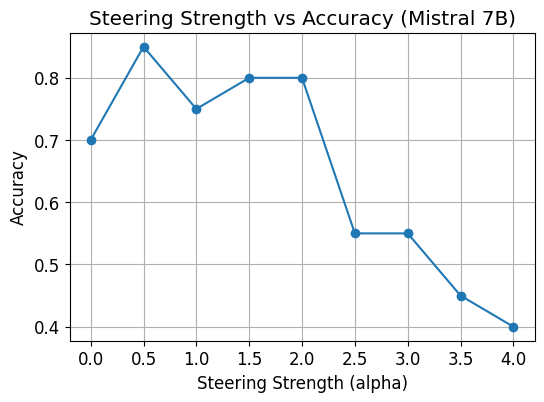

In [ ]:
import json
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (6,4)
})

save_path = '/content/drive/MyDrive/run2_phi/final_balanced_sweep_mistral.json'

with open(save_path, 'r') as f:
    data = json.load(f)

alphas = sorted([float(k) for k in data.keys()])
accuracies = [data[str(a)] for a in alphas]

plt.figure()
plt.plot(alphas, accuracies, marker='o')

plt.xlabel('Steering Strength (alpha)')
plt.ylabel('Accuracy')
plt.title('Steering Strength vs Accuracy (Mistral 7B)')

plt.grid(True)
plt.savefig('/content/drive/MyDrive/run2_phi/alpha_sweep_mistral.png', dpi=300)
plt.show()

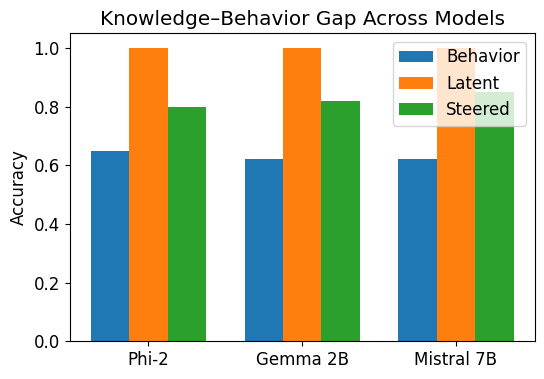

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (6,4)
})

models = ['Phi-2', 'Gemma 2B', 'Mistral 7B']

behavior = [0.65, 0.62, 0.62]
latent = [1.0, 1.0, 1.0]
steered = [0.80, 0.82, 0.85]

x = range(len(models))

plt.figure()

plt.bar(x, behavior, width=0.25, label='Behavior')
plt.bar([i + 0.25 for i in x], latent, width=0.25, label='Latent')
plt.bar([i + 0.5 for i in x], steered, width=0.25, label='Steered')

plt.xticks([i + 0.25 for i in x], models)
plt.ylabel('Accuracy')
plt.title('Knowledge–Behavior Gap Across Models')
plt.legend()

plt.savefig('/content/drive/MyDrive/run2_phi/model_comparison.png', dpi=300)
plt.show()

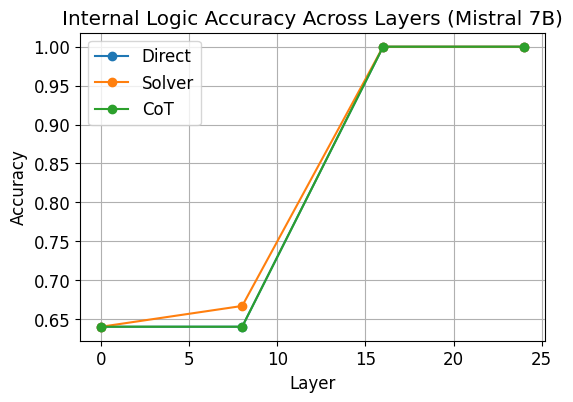

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (6,4)
})

layers = [0, 8, 16, 24]
direct = [0.64, 0.64, 1.0, 1.0]
solver = [0.64, 0.6667, 1.0, 1.0]
cot = [0.64, 0.64, 1.0, 1.0]

plt.figure()

plt.plot(layers, direct, marker='o', label='Direct')
plt.plot(layers, solver, marker='o', label='Solver')
plt.plot(layers, cot, marker='o', label='CoT')

plt.xlabel('Layer')
plt.ylabel('Accuracy')
plt.title('Internal Logic Accuracy Across Layers (Mistral 7B)')
plt.legend()
plt.grid(True)

plt.savefig('/content/drive/MyDrive/run2_phi/layer_probe_mistral.png', dpi=300)
plt.show()

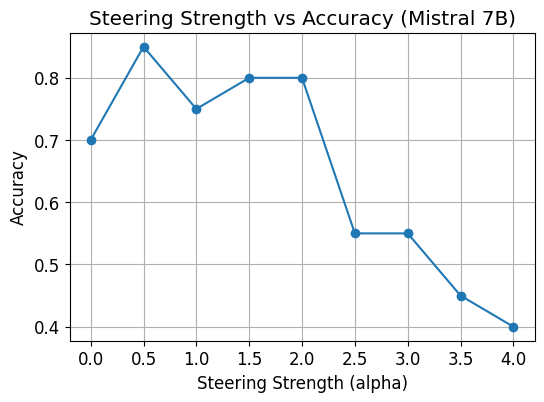

In [ ]:
import json
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (6,4)
})

save_path = '/content/drive/MyDrive/run2_phi/final_balanced_sweep_mistral.json'

with open(save_path, 'r') as f:
    data = json.load(f)

alphas = sorted([float(k) for k in data.keys()])
accuracies = [data[str(a)] for a in alphas]

plt.figure()
plt.plot(alphas, accuracies, marker='o')

plt.xlabel('Steering Strength (alpha)')
plt.ylabel('Accuracy')
plt.title('Steering Strength vs Accuracy (Mistral 7B)')

plt.grid(True)
plt.savefig('/content/drive/MyDrive/run2_phi/alpha_sweep_mistral.pdf', bbox_inches='tight')
plt.show()

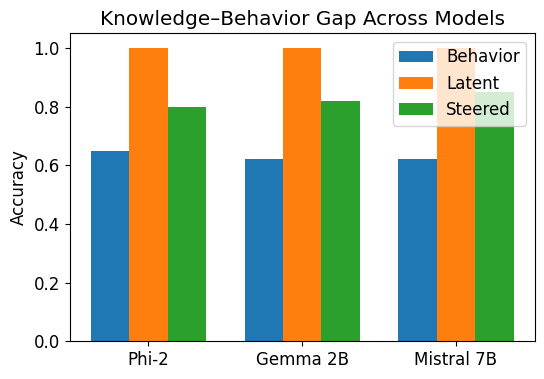

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (6,4)
})

models = ['Phi-2', 'Gemma 2B', 'Mistral 7B']

behavior = [0.65, 0.62, 0.62]
latent = [1.0, 1.0, 1.0]
steered = [0.80, 0.82, 0.85]

x = range(len(models))

plt.figure()

plt.bar(x, behavior, width=0.25, label='Behavior')
plt.bar([i + 0.25 for i in x], latent, width=0.25, label='Latent')
plt.bar([i + 0.5 for i in x], steered, width=0.25, label='Steered')

plt.xticks([i + 0.25 for i in x], models)
plt.ylabel('Accuracy')
plt.title('Knowledge–Behavior Gap Across Models')
plt.legend()

plt.savefig('/content/drive/MyDrive/run2_phi/model_comparison.pdf', bbox_inches='tight')
plt.show()

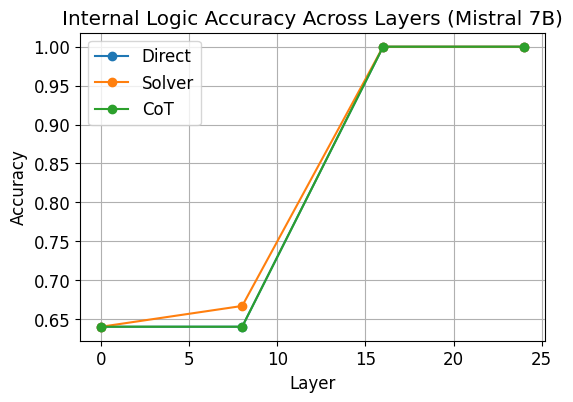

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (6,4)
})

layers = [0, 8, 16, 24]
direct = [0.64, 0.64, 1.0, 1.0]
solver = [0.64, 0.6667, 1.0, 1.0]
cot = [0.64, 0.64, 1.0, 1.0]

plt.figure()

plt.plot(layers, direct, marker='o', label='Direct')
plt.plot(layers, solver, marker='o', label='Solver')
plt.plot(layers, cot, marker='o', label='CoT')

plt.xlabel('Layer')
plt.ylabel('Accuracy')
plt.title('Internal Logic Accuracy Across Layers (Mistral 7B)')
plt.legend()
plt.grid(True)

plt.savefig('/content/drive/MyDrive/run2_phi/layer_probe_mistral.pdf', bbox_inches='tight')
plt.show()

In [ ]:
from datasets import load_dataset

dataset = load_dataset("gsm8k", "main", split="test")

# take small subset (fast)
dataset = dataset.select(range(50))

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_dataset

# 1. LOAD DATASET
gsm = load_dataset("gsm8k", "main", split="test")
gsm = gsm.select(range(50))  # keep small


def convert_to_binary(example, idx):
    question = example["question"]
    answer = example["answer"].split("####")[-1].strip()

    prompt = f"{question}\nIs the answer {answer}? Answer True or False."

    return {
        "prompt": prompt,
        "target": "True",
        "cluster_id": idx   # REQUIRED for your pipeline
    }

gsm_binary = [convert_to_binary(x, i) for i, x in enumerate(gsm)]

print("Sample:")
print(gsm_binary[0])


# 2. BASELINE RUN
def run_baseline(model, tokenizer, dataset):
    results = []

    for item in dataset:
        inputs = tokenizer(item["prompt"], return_tensors="pt").to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=50
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)

        pred = extract_answer_final(response)

        results.append(pred == item["target"])

    return results


baseline_acc = run_baseline(model, tokenizer, gsm_binary)
baseline = sum(baseline_acc) / len(baseline_acc)

print(f"\nBaseline Accuracy: {baseline:.2%}")


# 3. STEERING RUN
_, steered_acc = run_steered_test(
    model,
    tokenizer,
    gsm_binary,
    alpha=0.5
)

steered = sum(steered_acc) / len(steered_acc)

print(f"Steered Accuracy: {steered:.2%}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Sample:
{'prompt': "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?\nIs the answer 18? Answer True or False.", 'target': 'True', 'cluster_id': 0}


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o


Baseline Accuracy: 12.00%

Running Baseline (No Steering)...


StopIteration: 

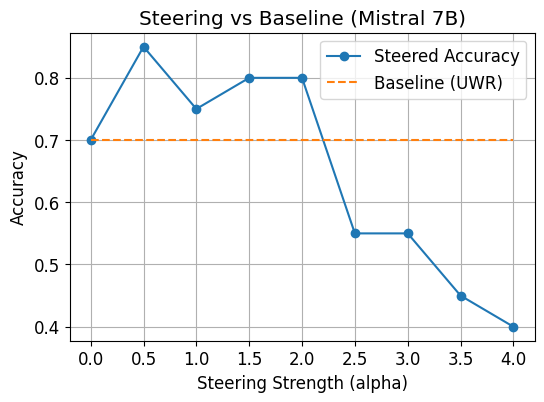

In [ ]:
import json
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (6,4)
})

# Load alpha sweep results
save_path = '/content/drive/MyDrive/run2_phi/final_balanced_sweep_mistral.json'

with open(save_path, 'r') as f:
    data = json.load(f)

alphas = sorted([float(k) for k in data.keys()])
steering_acc = [data[str(a)] for a in alphas]

#   BASELINE (UWR)
uwr = 0.70
uwr_line = [uwr] * len(alphas)

# Plot
plt.figure()

plt.plot(alphas, steering_acc, marker='o', label='Steered Accuracy')
plt.plot(alphas, uwr_line, linestyle='--', label='Baseline (UWR)')

plt.xlabel('Steering Strength (alpha)')
plt.ylabel('Accuracy')
plt.title('Steering vs Baseline (Mistral 7B)')

plt.legend()
plt.grid(True)

plt.savefig('/content/drive/MyDrive/run2_phi/alpha_with_uwr.pdf', bbox_inches='tight')
plt.show()

In [ ]:
def run_steered_test_nlp(model, tokenizer, dataset, alpha):

    results = []

    for item in dataset:
        prompt = item["prompt"]

        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        # --- Forward pass with hook ---
        with torch.no_grad():

            def hook_fn(module, input, output):
                return output + alpha * steering_vector

            handle = model.model.layers[STEER_LAYER].register_forward_hook(hook_fn)

            outputs = model.generate(
                **inputs,
                max_new_tokens=50
            )

            handle.remove()

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)

        pred = extract_answer_final(response)

        results.append(pred == item["target"])

    return results

In [ ]:
STEER_LAYER = 16
steered_acc = run_steered_test_nlp(
    model,
    tokenizer,
    gsm_binary,
    alpha=0.5
)

steered = sum(steered_acc) / len(steered_acc)

print(f"Steered Accuracy: {steered:.2%}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Steered Accuracy: 14.00%


In [ ]:
from datasets import load_dataset

dataset = load_dataset("boolq", split="validation")
dataset = dataset.select(range(100))  # small subset


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.69M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

In [ ]:
def convert_boolq(example, idx):
    question = example["question"]
    passage = example["passage"]
    answer = "True" if example["answer"] else "False"

    prompt = f"{passage}\n\nQuestion: {question}\nAnswer True or False."

    return {
        "prompt": prompt,
        "target": answer,
        "cluster_id": idx
    }

boolq_data = [convert_boolq(x, i) for i, x in enumerate(dataset)]

print(boolq_data[0])

{'prompt': "All biomass goes through at least some of these steps: it needs to be grown, collected, dried, fermented, distilled, and burned. All of these steps require resources and an infrastructure. The total amount of energy input into the process compared to the energy released by burning the resulting ethanol fuel is known as the energy balance (or ``energy returned on energy invested''). Figures compiled in a 2007 report by National Geographic Magazine point to modest results for corn ethanol produced in the US: one unit of fossil-fuel energy is required to create 1.3 energy units from the resulting ethanol. The energy balance for sugarcane ethanol produced in Brazil is more favorable, with one unit of fossil-fuel energy required to create 8 from the ethanol. Energy balance estimates are not easily produced, thus numerous such reports have been generated that are contradictory. For instance, a separate survey reports that production of ethanol from sugarcane, which requires a tro

In [ ]:
def extract_answer_tf(response):
    response = response.lower()

    if "true" in response:
        return "True"
    if "false" in response:
        return "False"

    return "Unknown"

In [ ]:
def run_baseline(model, tokenizer, dataset):
    results = []

    for item in dataset:
        inputs = tokenizer(item["prompt"], return_tensors="pt").to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=30
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)

        pred = extract_answer_tf(response)

        results.append(pred == item["target"])

    return results


baseline_acc = run_baseline(model, tokenizer, boolq_data)
baseline = sum(baseline_acc) / len(baseline_acc)

print(f"Baseline Accuracy: {baseline:.2%}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Baseline Accuracy: 70.00%


In [ ]:
STEER_LAYER = 16  # same as before

def run_steered_test_nlp(model, tokenizer, dataset, alpha):

    results = []

    for item in dataset:
        inputs = tokenizer(item["prompt"], return_tensors="pt").to(model.device)

        def hook_fn(module, input, output):
            return output + alpha * steering_vector

        handle = model.model.layers[STEER_LAYER].register_forward_hook(hook_fn)

        outputs = model.generate(
            **inputs,
            max_new_tokens=30
        )

        handle.remove()

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)

        pred = extract_answer_tf(response)

        results.append(pred == item["target"])

    return results


steered_acc = run_steered_test_nlp(
    model,
    tokenizer,
    boolq_data,
    alpha=0.5
)

steered = sum(steered_acc) / len(steered_acc)

print(f"Steered Accuracy: {steered:.2%}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Steered Accuracy: 70.00%
